In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from photutils.segmentation import detect_threshold
from photutils.segmentation import detect_sources
#from corner import corner
import photutils
import statmorph
import torch
from torch.utils.data import TensorDataset, DataLoader, Subset
import torch.utils.data as data_utils
import types
from multiprocessing import Pool
from itertools import repeat
from contextlib import ExitStack, redirect_stderr, redirect_stdout
import os

/gpfslocalsup/pub/anaconda-py3/2023.03/envs/pytorch-gpu-2.0.0+py3.10.9/lib/python3.10/site-packages/paramiko/transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


# Morphological parameters collect
If already done you can jump to the ploying section

In [2]:
def get_segmentation_map(image: np.array, npixels: int = 5):
    """ obtain segmentation map of biggest object in image
    
    Parameter
    ---------
    image : numpy.array
        contains the b/w image in 2D
    npixers : int
        minimum number of connected pixels
    """
    threshold = detect_threshold(image, 1.5)
    segm = detect_sources(image, threshold, npixels)
    # Keep only the largest segment
    label = np.argmax(segm.areas) + 1
    segmap = segm.data == label
    # regularize
    segmap_float = ndi.uniform_filter(np.float64(segmap), size=10)
    segmap = segmap_float > 0.5
    return segmap.astype(int)

In [3]:
class MorphoType(type):
    @property
    def concentration(cls):
        return -999.0
    @property
    def asymmetry(cls):
        return -999.0
    @property
    def smoothness(cls):
        return -999.0
    @property
    def multimode(cls):
        return -999.0
    @property
    def intensity(cls):
        return -999.0
    @property
    def deviation(cls):
        return -999.0
    @property
    def m20(cls):
        return -999.0
    @property
    def gini(cls):
        return -999.0
    @property
    def ellipticity_asymmetry(cls):
        return -999.0
       

class DefaultMorpho(metaclass=MorphoType):
    pass


In [4]:
measures_of_interest = ["concentration", "asymmetry", "smoothness",
                        "multimode", "intensity", "deviation", 
                        "m20", "gini",
                        "ellipticity_asymmetry"
                       ]

   
def get_morphology_measures(image: torch.Tensor, 
                            gain: float = 10000.0, # assume average of 10,000 electrons per pixel
                            silent: bool = True
                           ):
    """ return the morphology measures of a galaxy in an RGB image """
    image = image[0].squeeze()
    image = image.numpy()
    with ExitStack() as stack:
        if silent:
              stack.enter_context(redirect_stdout(open(os.devnull, 'w')))
              stack.enter_context(redirect_stderr(open(os.devnull, 'w')))
        try:
            segmap = get_segmentation_map(image)
            morphology_measures = statmorph.source_morphology(image, segmap, gain=gain)
            res = morphology_measures[0]
        except:
            res = DefaultMorpho
        return res

In [5]:
def get_morphology_measures_set(set: types.GeneratorType,
                               measures_of_interest: list = measures_of_interest,
                               N: int = 30,
                               ):
    """ obtain morphology measures for a set of galaxy images """
    measures = {m:[] for m in measures_of_interest}
    for i, image in enumerate(set):
        if i > N:
            break
        morph = get_morphology_measures(image)
        for key, value in measures.items():
            value.append(getattr(morph, key))
    return measures

def collect_morphology_measures(image):
    """ obtain morphology measures from galaxy image and add to collection. 
        Picklable function for parallel loop
    """
    morph = get_morphology_measures(image)
    return morph


def get_morphology_measures_set_parallel(set: types.GeneratorType,
                                         measures_of_interest: list = measures_of_interest,
                                         N: int = 30):
    """ obtain morphology measures for a set of galaxy images
        parallel computation is about 6 times faster on 16 cores
    """
    if N > 0:
        set = [next(set) for i in range(N)]
    with Pool() as pool:
        morphs = pool.map(collect_morphology_measures, set)
    measures = {m:[] for m in measures_of_interest}
    for morph in morphs:
        for key, value in measures.items():
            value.append(getattr(morph, key))
    return measures
        
        

In [6]:
measures_groups = {"CAS": ["concentration", "asymmetry", "smoothness",],
                   "gini-m20": ["m20", "gini",],
                  }


## Collect The original dataset

In [10]:
# last about 300sec for 10_000 spls

data_train = torch.load('../datasets/sdss_train_no_repeats_64x64.pt')  # shape [N,1,H,W]

offset = 0 # test 1Nov24 with offset=0
inputs_train  = data_train[offset:offset+10_000] # never been seen by any models


In [11]:
inputs_train.shape

torch.Size([10000, 1, 64, 64])

In [12]:
torch.min(inputs_train),torch.max(inputs_train)

(tensor(0.), tensor(1.))

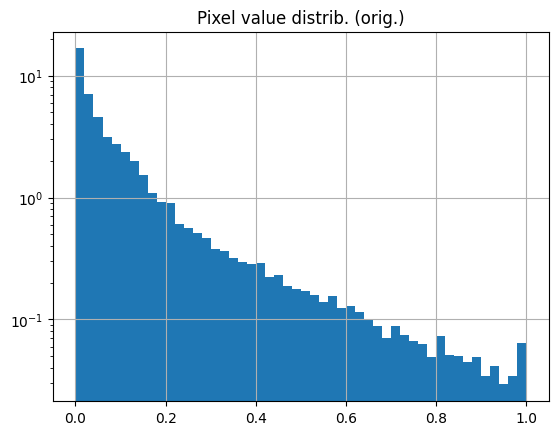

In [13]:
plt.hist(inputs_train[:10].flatten(),bins=50,density=True);
plt.yscale("log")
plt.grid();
plt.title("Pixel value distrib. (orig.)");

In [ ]:
train_dataset = TensorDataset(inputs_train)
train_data_loader = DataLoader(train_dataset, batch_size=1, shuffle=False,
                         drop_last=True, pin_memory=True, num_workers=4)
train_image_loader = (image for image in train_data_loader)
measures_train = get_morphology_measures_set_parallel(train_image_loader, N=0)

In [26]:
for k,v in measures_train.items():
    measures_train[k] = [newv for newv in v if newv != -999.0]

In [27]:
#np.save('measures_train_10000.npy', measures_train) 
np.save('measures_train_10000_offset_0.npy', measures_train) # test 1Nov24 

## Collect The Diffusion model

In [15]:
# last about 300sec for 10_000 spls
rootdir = "../diffusion_model_sdss/results/img_align_sdss_64x64/"
ntrain=1_000
diffusion_A_B_samples = torch.load(rootdir+"UNet_many_samples_"+str(ntrain)+"_10000.pt",
                                   map_location=torch.device('cpu'))
diffusion_samples = diffusion_A_B_samples['A']


In [16]:
diffusion_samples.shape

torch.Size([10000, 1, 64, 64])

In [17]:
torch.min(diffusion_samples),torch.max(diffusion_samples)

(tensor(-0.0295), tensor(2.3009))

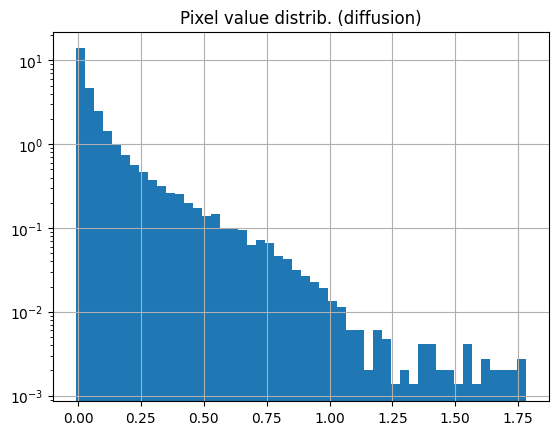

In [18]:
plt.hist(diffusion_samples[:10].flatten(),bins=50,density=True);
plt.yscale("log")
plt.grid();
plt.title("Pixel value distrib. (diffusion)");

In [19]:
diff_dataset = TensorDataset(diffusion_samples)
diff_data_loader = DataLoader(diff_dataset, batch_size=1, shuffle=False,
                         drop_last=True, pin_memory=True, num_workers=4)
diff_image_loader = (image for image in diff_data_loader)
measures_diff = get_morphology_measures_set_parallel(diff_image_loader, N=0)


In [20]:
for k,v in measures_diff.items():
    measures_diff[k] = [newv for newv in v if newv != -999.0]
    print(k,len(measures_diff[k]))

concentration 10000
asymmetry 10000
smoothness 10000
multimode 10000
intensity 10000
deviation 10000
m20 10000
gini 10000
ellipticity_asymmetry 10000


In [21]:
fname='measures_diff_'+str(ntrain)+'.npy'
fname

'measures_diff_1000.npy'

In [22]:
np.save(fname,measures_diff)

## Collect The Glow model
here was needed to proceed in two generated sample sets of 5000 each

In [7]:
#glow_A_samples_1 = torch.load('../glow-pytorch-sdss/glow_samples_100000_5000_1.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_2 = torch.load('../glow-pytorch-sdss/glow_samples_100000_5000_2.pt',
#                            map_location=torch.device('cpu'))

# new model 44Millions Param/ best model/ temeprature = 0.7
#glow_A_samples_1 = torch.load('../glow-pytorch-sdss/glow_samples_100000_new_A_4000_1.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_2 = torch.load('../glow-pytorch-sdss/glow_samples_100000_new_A_4000_2.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_3 = torch.load('../glow-pytorch-sdss/glow_samples_100000_new_A_2000.pt',
#                            map_location=torch.device('cpu'))

# new model 44Millions Param/ best model/ temeprature = 1.0
#glow_A_samples_1 = torch.load('../glow-pytorch-sdss/glow_samples_100000_new_A_4000_T1.0_1.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_2 = torch.load('../glow-pytorch-sdss/glow_samples_100000_new_A_4000_T1.0_2.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_3 = torch.load('../glow-pytorch-sdss/glow_samples_100000_new_A_2000_T1.0.pt',
#                            map_location=torch.device('cpu'))



#29Oct24 new model (n_block=3 affine) 44Millions Param/ best model/ temeprature = 1.0 / no clipping gradiant
#glow_A_samples_1 = torch.load('../glow-pytorch-sdss/glow_samples_100000_2ndmod_noclip_A_4000_T1.0_1.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_2 = torch.load('../glow-pytorch-sdss/glow_samples_100000_2ndmod_noclip_A_4000_T1.0_2.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_3 = torch.load('../glow-pytorch-sdss/glow_samples_100000_2ndmod_noclip_A_2000_T1.0.pt',
#                            map_location=torch.device('cpu'))


#1Nov24 new model (n_block=5 affine) 128Millions Param/ best model/ temeprature = 1.0 / clipping gradiant
#2Nov24 new post_processing & rgb->gray 
#glow_A_samples_1 = torch.load('../glow-pytorch-sdss/glow_samples_100000_3rdmod_clip_A_4000_T1.0_1.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_2 = torch.load('../glow-pytorch-sdss/glow_samples_100000_3rdmod_clip_A_4000_T1.0_2.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_3 = torch.load('../glow-pytorch-sdss/glow_samples_100000_3rdmod_clip_A_2000_T1.0.pt',
#                            map_location=torch.device('cpu'))


#3Nov24
rootdir='../glow-pytorch-sdss/archive_100000_2nd_model_cured_glow_sdss/'
# new model 44Millions Param/ best model/ temeprature = 1.0
glow_A_samples_1 = torch.load(rootdir+'glow_samples_100000_2ndmod_A_4000_T1.0_1.pt',
                            map_location=torch.device('cpu'))
glow_A_samples_2 = torch.load(rootdir+'glow_samples_100000_2ndmod_A_4000_T1.0_2.pt',
                            map_location=torch.device('cpu'))
glow_A_samples_3 = torch.load(rootdir+'glow_samples_100000_2ndmod_A_2000_T1.0.pt',
                            map_location=torch.device('cpu'))
glow_samples = torch.vstack((glow_A_samples_1['A'],glow_A_samples_2['A']))
#glow_samples = torch.vstack((glow_A_samples_1['A'],glow_A_samples_2['A'],glow_A_samples_3['A']))

#11 nov24 same as 3Nov24 but with "B" model
#glow_B_samples_1 = torch.load('../glow-pytorch-sdss/archive_2nd_model_cured_glow_sdss/glow_samples_100000_2ndmod_B_4000_T1.0_1.pt',
#                            map_location=torch.device('cpu'))
#glow_B_samples_2 = torch.load('../glow-pytorch-sdss/archive_2nd_model_cured_glow_sdss/glow_samples_100000_2ndmod_B_4000_T1.0_2.pt',
#                            map_location=torch.device('cpu'))
#glow_B_samples_3 = torch.load('../glow-pytorch-sdss/archive_2nd_model_cured_glow_sdss/glow_samples_100000_2ndmod_B_2000_T1.0.pt',
#                            map_location=torch.device('cpu'))
#glow_samples = torch.vstack((glow_B_samples_1['B'],glow_B_samples_2['B'],glow_B_samples_3['B']))

#23Nov24
# model A trained with 10000 & 1000 images
#ntrain=10_000
#rootdir='../glow-pytorch-sdss/archive_'+str(ntrain)+'_2nd_model_cured_glow_sdss/'
#glow_A_samples_1 = torch.load(rootdir+'glow_samples_'+str(ntrain)+'_2ndmod_4000_T1.0_1.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_2 = torch.load(rootdir+'glow_samples_'+str(ntrain)+'_2ndmod_4000_T1.0_2.pt',
#                            map_location=torch.device('cpu'))
#glow_A_samples_3 = torch.load(rootdir+'glow_samples_'+str(ntrain)+'_2ndmod_2000_T1.0.pt',
#                            map_location=torch.device('cpu'))

#glow_samples = torch.vstack((glow_A_samples_1['A'],glow_A_samples_2['A'],glow_A_samples_3['A']))



In [8]:
glow_samples.shape

torch.Size([8000, 1, 64, 64])

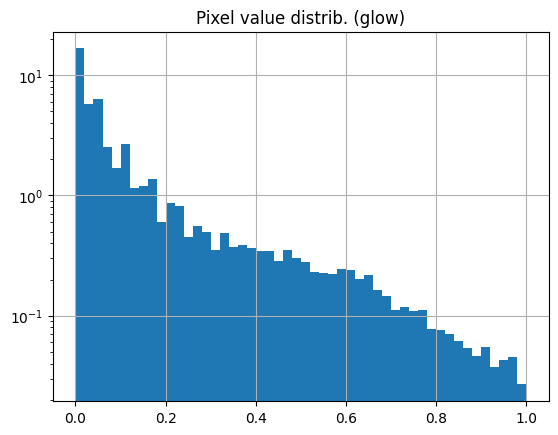

In [9]:
plt.hist(glow_samples[:10].flatten(),bins=50,density=True);
plt.yscale("log")
plt.grid();
plt.title("Pixel value distrib. (glow)");

In [ ]:
# last about 800sec for 10_000 spls
glow_dataset = TensorDataset(glow_samples)
glow_data_loader = DataLoader(glow_dataset, batch_size=1, shuffle=False,
                         drop_last=True, pin_memory=True, num_workers=4)
glow_image_loader = (image for image in glow_data_loader)
measures_glow = get_morphology_measures_set_parallel(glow_image_loader, N=0)

In [ ]:
for k,v in measures_glow.items():
    measures_glow[k] = [newv for newv in v if newv != -999.0]
    print(k,len(measures_glow[k]))

In [ ]:
#np.save('measures_glow_10000_2ndmod_T1.0_A.npy',measures_glow)  # 23Nov24
#np.save('measures_glow_1000_2ndmod_T1.0_A.npy',measures_glow)  # 23Nov24
np.save('measures_glow_100000_2ndmod_T1.0_A.npy',measures_glow)

## Collect The Lightweight-GAN model

In [16]:
#gan_samples = np.load("../lightweight-gan/results/train_100000_A-generated-101/gan-samples_10000.npy")

ntrain=1_000
model="A"
#11Nov24
#gan_samples = np.load("../lightweight-gan/results/train_"+str(ntrain)+"_noaugatall_"+model+"-generated-147/gan-samples_10000.npy")
#6dec24
gan_samples = np.load("../lightweight-gan/results/train_"+str(ntrain)+"_noaugatall_"+model+"-generated-150/gan-samples_10000.npy")


In [17]:
gan_samples= np.expand_dims(gan_samples, axis=(1,))
gan_samples = torch.asarray(gan_samples,device='cpu')

In [18]:
gan_samples.shape

torch.Size([10000, 1, 64, 64])

In [19]:
torch.min(gan_samples),torch.max(gan_samples)

(tensor(0, dtype=torch.uint8), tensor(255, dtype=torch.uint8))

In [20]:
gan_samples = gan_samples.to(dtype=torch.float32)/255.

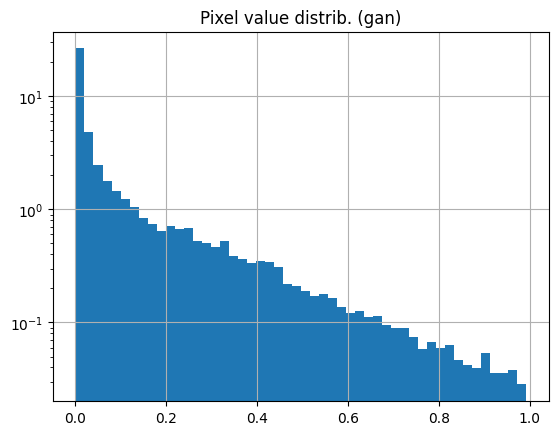

In [21]:
plt.hist(gan_samples[:10].flatten(),bins=50,density=True);
plt.yscale("log")
plt.grid();
plt.title("Pixel value distrib. (gan)");

In [22]:
# last about 300-900sec for 10_000 spls
gan_dataset = TensorDataset(gan_samples)
gan_data_loader = DataLoader(gan_dataset, batch_size=1, shuffle=False,
                         drop_last=True, pin_memory=True, num_workers=4)
gan_image_loader = (image for image in gan_data_loader)
measures_gan = get_morphology_measures_set_parallel(gan_image_loader, N=0)

In [23]:
for k,v in measures_gan.items():
    measures_gan[k] = [newv for newv in v if newv != -999.0]
    print(k,len(measures_gan[k]))

concentration 10000
asymmetry 10000
smoothness 10000
multimode 10000
intensity 10000
deviation 10000
m20 10000
gini 10000
ellipticity_asymmetry 10000


In [24]:
#np.save('measures_gan_10000_rescale.npy',measures_gan)
np.save("meaures_gan_2ndmod_noaugatall_"+model+"_"+str(ntrain)+".npy",measures_gan)

# Ploting

In [25]:
measures_groups = {"CAS": ["concentration", "asymmetry", "smoothness",],
                   "gini-m20": ["m20", "gini",],
                  }


In [26]:
def plot_corner(*data, **kwargs):
    d = np.array(*data).T
    #print(d.shape)
    fig = corner(d, **kwargs)
    return fig


def read_measures(keys: list, measures: dict ):
    """ obtain group of measures from full dict 
    
    Parameter
    ---------
    keys: list
        list of names (str) of measures to be read
    measures: dict
        full dict containing all measures
    """
    return [measures[k] for k in keys]


def read_measures_group(group: str, measures: dict):
    """ obtain group of measures from full dict 
    
    Parameter
    ---------
    group: str
        name of group of morphology measures. 
        (keys of measures_groups)
    measures: dict
        full dict containing all measures
    """
    keys = measures_groups[group]
    return read_measures(keys, measures)

def plot_corner_measures_group(group: str, measures: dict, **kwargs):
    """ create corner plot of group of measures
    
    Parameter
    ---------
    group: str
        name of group of morphology measures. 
        (keys of measures_groups)
    measures: dict
        full dict containing all measures
    """
    labels = [m for m in measures_groups[group]]
    data = read_measures_group(group, measures)
    return plot_corner(data, labels=labels, **kwargs)

In [27]:
measures_train = np.load('measures_train_10000.npy',allow_pickle='TRUE').item() # in the validation dataset
#measures_train = np.load('measures_train_10000_offset_0.npy',allow_pickle='TRUE').item()

measures_glow_100000 = np.load('measures_glow_100000_2ndmod_T1.0_A.npy',allow_pickle='TRUE').item()
#measures_glow_10000 = np.load('measures_glow_10000_2ndmod_T1.0_A.npy',allow_pickle='TRUE').item()
#measures_glow_1000 = np.load('measures_glow_1000_2ndmod_T1.0_A.npy',allow_pickle='TRUE').item()


measures_diff_100000 =  np.load('measures_diff_100000.npy',allow_pickle='TRUE').item()
#measures_diff_10000 =  np.load('measures_diff_10000.npy',allow_pickle='TRUE').item()
#measures_diff_1000 =  np.load('measures_diff_1000.npy',allow_pickle='TRUE').item()

measures_gan_100000 =  np.load("meaures_gan_2ndmod_noaugatall_A_100000.npy",allow_pickle='TRUE').item()
measures_gan_10000 =  np.load("meaures_gan_2ndmod_noaugatall_A_10000.npy",allow_pickle='TRUE').item()
measures_gan_1000 =  np.load("meaures_gan_2ndmod_noaugatall_A_1000.npy",allow_pickle='TRUE').item()


#measures_gan_A = np.load('meaures_gan_2ndmod_noaugatall_A_10000.npy',allow_pickle='TRUE').item() # 11nov24
#measures_gan_B = np.load('meaures_gan_2ndmod_noaugatall_B_10000.npy',allow_pickle='TRUE').item() # 11Nov24

In [28]:
measures_groups.keys()

dict_keys(['CAS', 'gini-m20'])

In [29]:
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

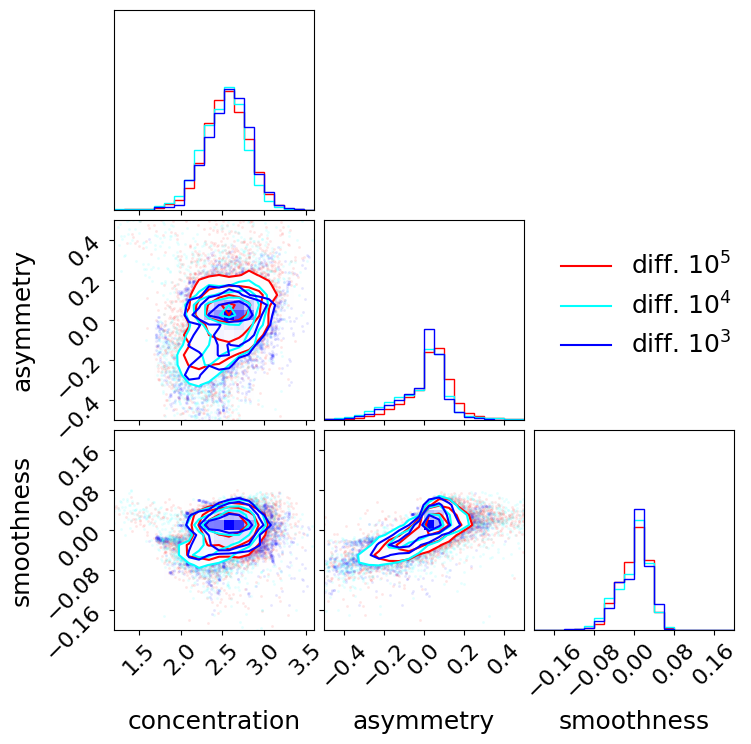

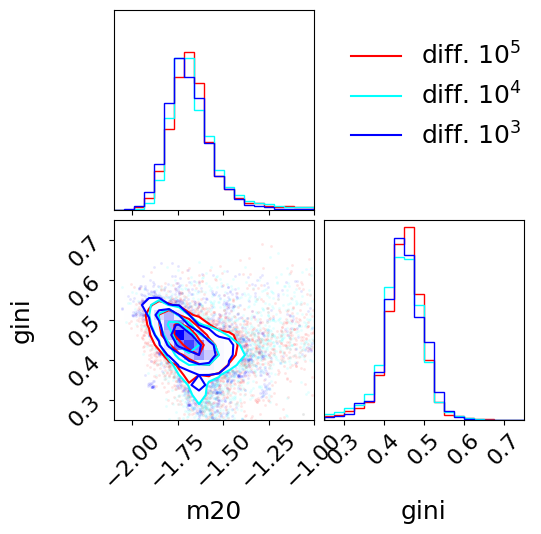

In [32]:
from corner import corner
import matplotlib.lines as mlines

#ntrain=100_000
#tag="All"
#colors = ["red","blue","green","cyan"]
#sample_labels = ["test","diffusion","glow","gan"]
#measaures_gen = [measures_diff_100000,measures_glow_100000,measures_gan_100000]
#test_included=True

#ntrain=0
#tag="glow-compare"
#colors = ["red","cyan","blue"]
#sample_labels = [r"glow $10^5$", r"glow $10^4$", r"glow $10^3$"]
#measaures_gen = [measures_glow_100000, measures_glow_10000, measures_glow_1000]
#test_included=False

#ntrain=0
#tag="diff-compare"
#colors = ["red","cyan","blue"]
#sample_labels = [r"diff. $10^5$", r"diff. $10^4$", r"diff. $10^3$"]
#measaures_gen = [measures_diff_100000, measures_diff_10000, measures_diff_1000]
#test_included=False

ntrain=0
tag="gan-compare"
colors = ["red","cyan","blue"]
sample_labels = [r"diff. $10^5$", r"diff. $10^4$", r"diff. $10^3$"]
measaures_gen = [measures_gan_100000, measures_gan_10000, measures_gan_1000]
test_included=False



n = len(colors)
ndim = len(measures_groups.keys())

for i,group in enumerate(measures_groups.keys()):
    if group == "CAS":
        _range=[(1.2, 3.6), (-0.5, 0.5), (-0.2, 0.2)]
    else:
        _range=[(-2.1,-1.0),(0.25,0.75)]

    if test_included:
        fig=plot_corner_measures_group(group,measures_train, bins=20,
                                   color=colors[0],range=_range,
                                   #label_kwargs=dict(fontsize=16),
                                       labelpad=0.1,
                                   hist_kwargs={"density":True,"histtype":"stepfilled","alpha":0.5})
    
    for j,measures_ in enumerate(measaures_gen):
        jdx = j+1 if test_included else j
        if (not test_included) and (j==0):
            fig = plot_corner_measures_group(group,measures_, bins=20, color=colors[jdx],
                               range=_range,
                                              labelpad=0.1,
                                             #label_kwargs=dict(fontsize=16),
                                    hist_kwargs={"density":True})
        else:
            fig = plot_corner_measures_group(group,measures_, bins=20, color=colors[jdx],
                               fig=fig,range=_range,
                                              labelpad=0.1,
                                             #label_kwargs=dict(fontsize=16),
                                hist_kwargs={"density":True})

    
    if group == "CAS":
        ax_list = fig.axes
        fct=[1.5,2,1.5]
        for k,ax in enumerate([ax_list[0],ax_list[4],ax_list[8]]):
            b,t = ax.get_ylim()
            ax.set_ylim([b,t*fct[k]])
    else: 
        ax_list = fig.axes
        fct=[1.2,1.0]
        for k,ax in enumerate([ax_list[0],ax_list[3]]):
            b,t = ax.get_ylim()
            ax.set_ylim([b,t*fct[k]])
    
    plt.legend(
        handles=[
            mlines.Line2D([], [], color=colors[i], label=sample_labels[i])
            for i in range(n)
        ],
        fontsize=18, frameon=False,
        bbox_to_anchor=(1.10, ndim), loc="upper right"
    )

    plt.savefig("./fig-"+group+"-"+tag+"_"+str(ntrain)+".pdf")
    plt.show()